# **Data Science Project - Penguins**

The following project performs a full cycle of the data science process on a dataset called 'penguins'.

The following will be performed in this project:

- Discovering, cleaning, validating and structuring the dataset.
- Exploring the data through a series of visualisations.
- Constructing a Simple Linear Regression Model, a K-Means Clustering model and a Random Forest Classification model.
- Optimising the models to produce the best results and evaluating the models to understand their performance.
- Summary of insights gained.

Firstly, all libraries and packages required will be imported.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.formula.api import ols

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


Next we will import the penguins dataset.

In [ ]:
df = pd.read_csv('penguins.csv')

## **Exploratory Data Analysis**

### **Data discovery**

In [ ]:
df.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


There are four floats and three strings.

In [ ]:
df.describe(include='all')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,male
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


No outliers are present within the dataset.

### **Data Cleaning**

Check for missing values.

In [ ]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


Drop missing values, as there are only 2 missing entries.

In [ ]:
df = df.dropna(axis=0).reset_index(drop = True)

Check for duplicates.

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicates.

Here I would have also checked for outliers, but it was already discovered in the previous section that there are no outliers.

### **Data Validation**

Check labels for each categorical column to ensure consistency.

In [ ]:
df['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [ ]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [ ]:
df['sex'].unique()

array(['male', 'female'], dtype=object)

All labels are consistent.

Let's now check for class imabalances.

In [ ]:
df['species'].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


In [ ]:
df['island'].value_counts()

,count
island,
Biscoe,163
Dream,123
Torgersen,47


In [ ]:
df['sex'].value_counts()

,count
sex,
male,168
female,165


The sex column has a balanced distributed in the data, however the species has one particular value that is not as common and the island has one value that is particularly underrepresented.

We can leave these as of now.

### **Data Structuring**

Let's drop the island column since we will not be using that in our analysis.

In [ ]:
df = df.drop(['island'], axis = 1)
df

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,39.1,18.7,181.0,3750.0,male
1,Adelie,39.5,17.4,186.0,3800.0,female
2,Adelie,40.3,18.0,195.0,3250.0,female
3,Adelie,36.7,19.3,193.0,3450.0,female
4,Adelie,39.3,20.6,190.0,3650.0,male
...,...,...,...,...,...,...
328,Gentoo,47.2,13.7,214.0,4925.0,female
329,Gentoo,46.8,14.3,215.0,4850.0,female
330,Gentoo,50.4,15.7,222.0,5750.0,male
331,Gentoo,45.2,14.8,212.0,5200.0,female


Let's also convert the gender column to numeric through one-hot encoding. This will be important later.

In [ ]:
df = pd.get_dummies(df, columns=['sex'])
df

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_female,sex_male
0,Adelie,39.1,18.7,181.0,3750.0,False,True
1,Adelie,39.5,17.4,186.0,3800.0,True,False
2,Adelie,40.3,18.0,195.0,3250.0,True,False
3,Adelie,36.7,19.3,193.0,3450.0,True,False
4,Adelie,39.3,20.6,190.0,3650.0,False,True
...,...,...,...,...,...,...,...
328,Gentoo,47.2,13.7,214.0,4925.0,True,False
329,Gentoo,46.8,14.3,215.0,4850.0,True,False
330,Gentoo,50.4,15.7,222.0,5750.0,False,True
331,Gentoo,45.2,14.8,212.0,5200.0,True,False


More data structuring will be completed later on during the development of each model.

### **Data Visualisations**

Let's create some data visualisations to further explore and understand the dataset.

First let's create a couple box plot to visualise the distibution of bill length, bill depth, flipper length and body mass.

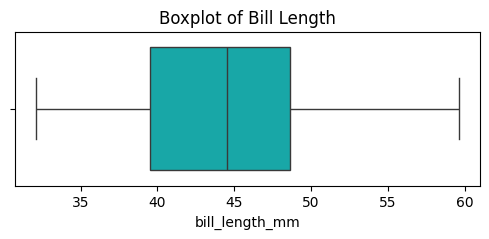

In [ ]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df['bill_length_mm'], color='c')
plt.title('Boxplot of Bill Length')
plt.show()

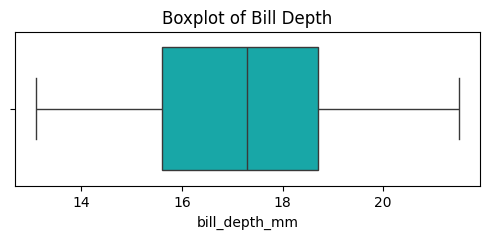

In [ ]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df['bill_depth_mm'], color='c')
plt.title('Boxplot of Bill Depth')
plt.show()

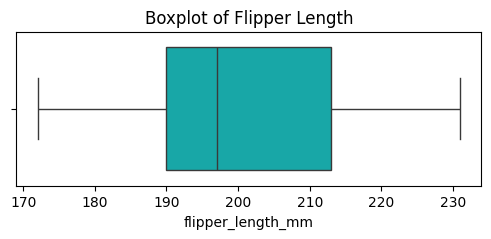

In [ ]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df['flipper_length_mm'], color='c')
plt.title('Boxplot of Flipper Length')
plt.show()

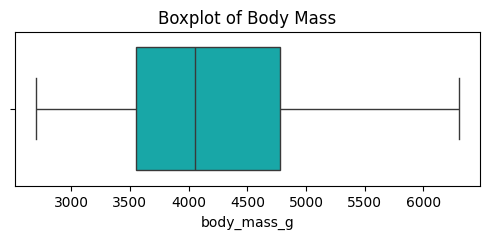

In [ ]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df['body_mass_g'], color='c')
plt.title('Boxplot of Body Mass')
plt.show()

All variables somewhat display what seems to a be normal distribution, nothing particularly interesting here.

Let's create two bar charts, one for species and for sex. Both plots will measure the average body mass.

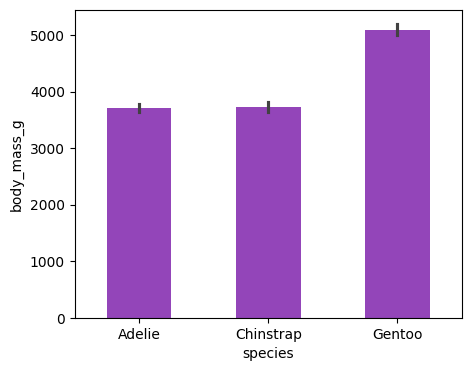

In [ ]:
plt.figure(figsize=(5, 4))
sns.barplot(data=df, x='species', y='body_mass_g', color='darkorchid', width=0.5)
plt.show()

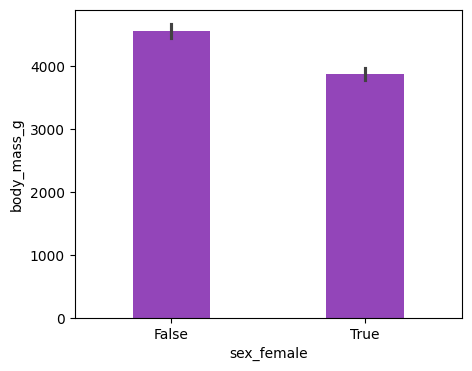

In [ ]:
plt.figure(figsize=(5, 4))
sns.barplot(data=df, x='sex_female', y='body_mass_g', color='darkorchid', width=0.4)
plt.show()

The 'Gentoo' species seeems to have an average weight just over 1 kg above the other two species.

Additionally, male penguinss are on average half a kg heavier than female penguins.

I would now like to create two scatterplots. The first will be flipper length again body mass and the second will be bill length against bill depth.

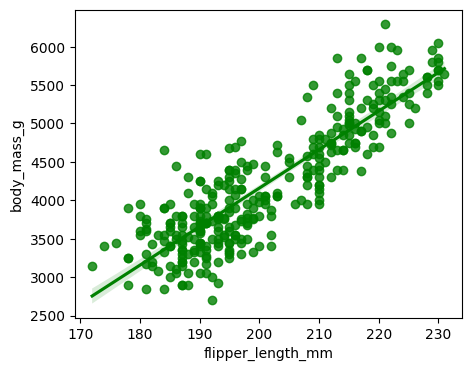

In [ ]:
plt.figure(figsize=(5, 4))
sns.regplot(data=df, x='flipper_length_mm', y='body_mass_g', color='green')
plt.show()

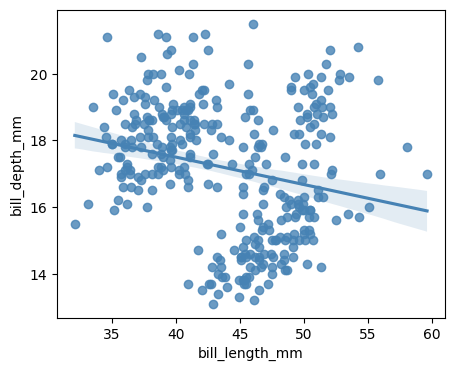

In [ ]:
plt.figure(figsize=(5, 4))
sns.regplot(data=df, x='bill_length_mm', y='bill_depth_mm', color='steelblue')
plt.show()

The first plot is what was expected, a strong positive correction between flipper length and body mass.

The second chart, however, was not entirely obvious. There seems to be a weak negative correlation between bill length and bill depth.

Finally, lets create a heatmap to visualise the correlation of all numeric variables within the dataset.

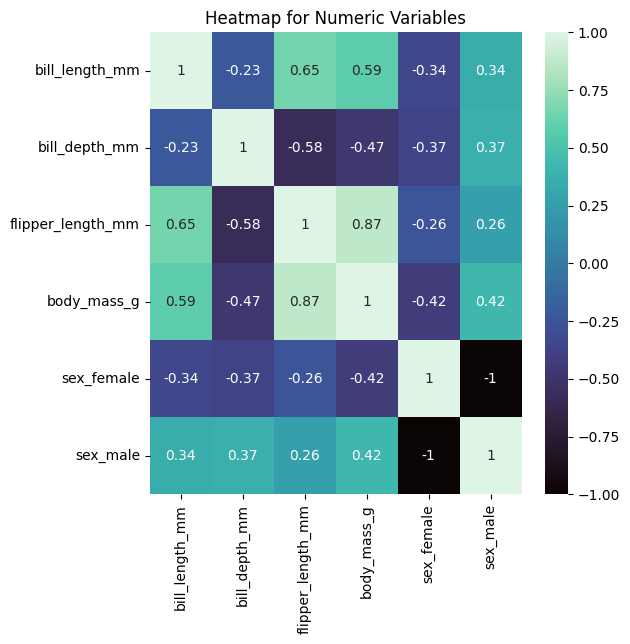

In [ ]:
plt.figure(figsize=(6, 6))
sns.heatmap(df.drop(['species'], axis=1).corr(), annot=True, cmap=sns.color_palette('mako', as_cmap=True))
plt.title('Heatmap for Numeric Variables')
plt.show()

It seems as though male penguins have a higher mass, bills with greater depth, bills with greater length and flippers with greater length. Some of these are more correlated than others.

Another interesting insight is that body mass and flipper length have a moderate negative correlation with bill depth.

## **Model Creation**

### **Simple Linear Regression**

We will plot a simple linear regression model to predict body mass using flipper length.

### Assumptions

There are four assumptions associated with a simple linear regression model:

- Linearity (confirmed from the charts above)
- Independent observation (each entry is an independent penguin)
- Normality (will be checked later)
- Homoscedasticity (will be checked later)

Let's build the model:

In [ ]:
formula = 'body_mass_g ~ flipper_length_mm'

OLS = ols(formula = formula, data = df)

model  = OLS.fit()

results = model.summary()

Now that the model is built, we can check the other two assumptions (normality and homoscedasticity).

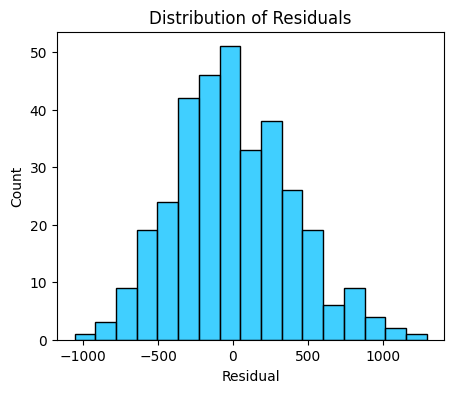

In [ ]:
residuals = model.resid

plt.figure(figsize=(5,4))
sns.histplot(residuals, color='deepskyblue')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.show()

The observations seem to be reasonably normally distributed, so we can confirm the assumption of normality.

In [ ]:
values = model.predict(df['flipper_length_mm'])

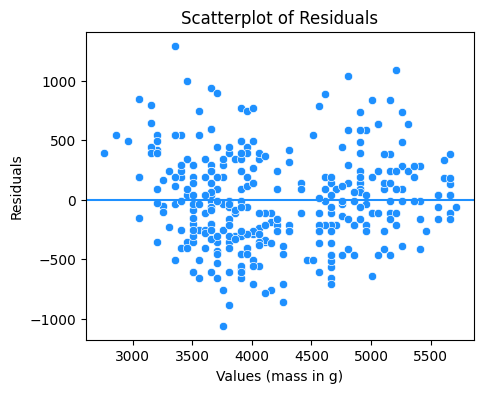

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(x = values, y = residuals, color = 'dodgerblue')
plt.axhline(y=0, color='dodgerblue')
plt.title('Scatterplot of Residuals')
plt.xlabel('Values (mass in g)')
plt.ylabel('Residuals')
plt.show()

The obsevations are randomly distributed with no obvious pattern. We can assume the homoscedasticity assumption has been met.

Now that all assumptions have been confirmed, we can confident that the model is valid. As a result we can now evaluate the model.

### Model Evaluation

Let's get a summary of the model results.

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          3.13e-105
Time:                        01:42:16   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5872.0927    310.285    -18.925      0.000   -6482.472   -5261.713
flipper_length_mm    50.1533      1.540     32.562      0.000      47.123      53.183
==============================================================================
Omnibus:                        5.922   Durbin-Watson:                   2.102
Prob(Omnibus):                  0.052   Jarque-Bera (JB):                5.876
Skew:                           0.325   Prob(JB):                       0.0530
Kurtosis:                       3.025   Cond. No.                     2.90e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.9e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The equation for this model is 50.1533 * x - 5872.0927.

The R-squared value is 0.762, which means that 76.2% of the penguins mass is explained by the flipper length. This is a reasonably strong value.

The P-Value is very low, indicating that there is indeed a relationship.

This model can be used to predict a penguins mass given its flipper length with reasonable accuracy.

### **K-Means Clustering**

Let's now build a K-Means clustering model on the data. Our goal is to cluster the 'species' attribute.

### Model Creation

First we need to scale the features so that the model treats all features equally.

In [ ]:
X = df.drop(['species'], axis = 1)

X_scaled = StandardScaler().fit_transform(X)

Next we will determine the appropriate number of clusters. We will use the intertia and silhouette score of each model (comprising 2 clusters to 6 clusters) to calculate this number.

In [ ]:
inertia = []
silhouette = []
for i in range(2, 7):
  KModel = KMeans(n_clusters = i, random_state=1)
  KModel.fit(X_scaled)
  inertia.append(KModel.inertia_)
  silhouette.append(silhouette_score(X_scaled, KModel.labels_))

print(inertia)
print(silhouette)

[1164.5010007992494, 732.8633716420007, 386.14534424773325, 314.8603093594423, 218.05156297830223]
[np.float64(0.41505912272609324), np.float64(0.4675885039785735), np.float64(0.5737870530594789), np.float64(0.5410273679443055), np.float64(0.5431422680188858)]


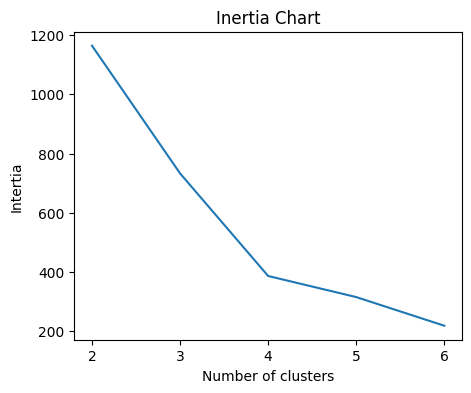

In [ ]:
plt.figure(figsize=(5,4))
clusterRange = [i for i in range(2, 7)]
sns.lineplot(x = clusterRange, y = inertia)
plt.title('Inertia Chart')
plt.xlabel('Number of clusters')
plt.ylabel('Intertia')
plt.xticks([2,3,4,5,6])
plt.show()

The elbow seems to be at 4, so lets use this value. We will now use the silhoutte score to further confirm this.

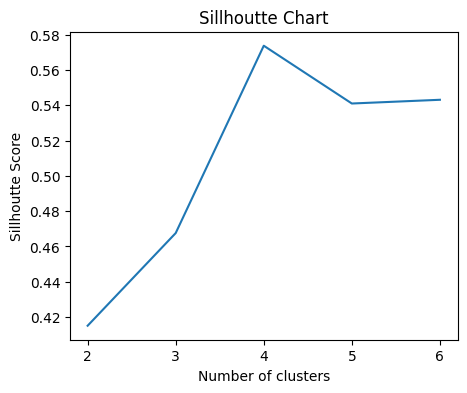

In [ ]:
plt.figure(figsize=(5,4))
sns.lineplot(x = clusterRange, y = silhouette)
plt.title('Sillhoutte Chart')
plt.xlabel('Number of clusters')
plt.ylabel('Sillhoutte Score')
plt.xticks([2,3,4,5,6])
plt.show()

The chart shows the most promising score at 4 clusters, which confirms our previous assumptions.

Now that we have our optimal cluster value, lets fit a model with 4 clusters.

In [ ]:
KMeans_Optimal = KMeans(n_clusters = 4, random_state=1)
KMeans_Optimal.fit(X_scaled)

KMeans(n_clusters=4, random_state=1)

Lets now append the class labels to our previous unscaled dataset (since its easier to interpret) and save this into a new dataframe.

In [ ]:
df_clustered = df.copy()
df_clustered['class'] = KMeans_Optimal.labels_

df_clustered.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_female,sex_male,class
0,Adelie,39.1,18.7,181.0,3750.0,False,True,2
1,Adelie,39.5,17.4,186.0,3800.0,True,False,0
2,Adelie,40.3,18.0,195.0,3250.0,True,False,0
3,Adelie,36.7,19.3,193.0,3450.0,True,False,0
4,Adelie,39.3,20.6,190.0,3650.0,False,True,2


### Model Evaluation

Let's now group the clusters by species to see the results.

In [ ]:
df_clustered.groupby(by=['class', 'species']).size()

class  species  
0      Adelie       73
       Chinstrap    34
1      Gentoo       61
2      Adelie       73
       Chinstrap    34
3      Gentoo       58
dtype: int64

Clusters 1 and 3 seem to have clustered only the 'Gentoo' species, which is good to see (however this could have been clustered to one cluster). Clusters 0 and 2, however, have clusted both 'Adelie' and 'Chinstrap' penguins, when in fact they should have been clustered seperately.

Let's see what happens if we differentiate the clusters by sex.

In [ ]:
df_clustered.groupby(by=['class', 'species', 'sex_female']).size()

class  species    sex_female
0      Adelie     True          73
       Chinstrap  True          34
1      Gentoo     False         61
2      Adelie     False         73
       Chinstrap  False         34
3      Gentoo     True          58
dtype: int64

The clusters are strongly differentiated by the sex of the penguin. This may explain the reason why we didn't get the three species clusters we expected.

Let's try to remove these variables and analyse the effects on the model.

In [ ]:
X2 = df.drop(['species','sex_female','sex_male'], axis = 1)

X_scaled2 = StandardScaler().fit_transform(X2)

KMeans_Optimal2 = KMeans(n_clusters = 3, random_state=1)
KMeans_Optimal2.fit(X_scaled2)

df_clustered2 = df.copy()
df_clustered2['class'] = KMeans_Optimal2.labels_

df_clustered2.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_female,sex_male,class
0,Adelie,39.1,18.7,181.0,3750.0,False,True,0
1,Adelie,39.5,17.4,186.0,3800.0,True,False,0
2,Adelie,40.3,18.0,195.0,3250.0,True,False,0
3,Adelie,36.7,19.3,193.0,3450.0,True,False,0
4,Adelie,39.3,20.6,190.0,3650.0,False,True,0


In [ ]:
df_clustered2.groupby(by=['class', 'species']).size()

class  species  
0      Adelie       124
       Chinstrap      5
1      Gentoo       119
2      Adelie        22
       Chinstrap     63
dtype: int64

This model does seem a lot more closely aligned with what we expect. Class 1 has only 'Gentoo' penguins, class 0 is almost completely comprised of 'Adelie' penguins and class 2 has a majority class of 'Chinstrap' penguins.

### **Random Forest Classification**

Next, we will create a random forest to predict the sex of the penguin.

### Model Creation

A random forest requires all variables to be numeric, so let's convert the 'species' column into numeric and save this into a new dataframe.

In [ ]:
df_classification = pd.get_dummies(df, columns=['species'])

We will also need to remove the 'sex_male' column so that to model doesn't use this to achieve 100% accuracy.

In [ ]:
df_classification = df_classification.drop(['sex_male'], axis = 1)

Next we can split the data into labels and features.

In [ ]:
X = df_classification.drop(['sex_female'], axis=1)
y = df_classification['sex_female']

Let's now create a training and testing split.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=1)

We can confirm the data was split accurately with the following command.

In [ ]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(249, 7) (84, 7) (249,) (84,)


We will now create a random forest model, a list of hyperparameters to optimise and set the scoring metric the model will use for evaluation.

In [ ]:
RF = RandomForestClassifier(random_state = 1)

params = {'max_depth' : [3, 4, 6],
          'max_features' : [2, 4, None],
          'max_samples' : [0.7, 1],
          'n_estimators' : [50, 100, 150]}

scoring = 'f1'

Let's now create the grid search and fit the data.

In [ ]:
RF_Optimise = GridSearchCV(RF, params, scoring=scoring, cv=5, refit='f1')

RF_Optimise.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=1),
             param_grid={'max_depth': [3, 4, 6], 'max_features': [2, 4, None],
                         'max_samples': [0.7, 1],
                         'n_estimators': [50, 100, 150]},
             refit='f1', scoring='f1')

Here are the best parameters:

In [ ]:
RF_Optimise.best_params_

{'max_depth': 6, 'max_features': 4, 'max_samples': 0.7, 'n_estimators': 150}

Let's get the best estimator and use it to make predictions on the test data.

In [ ]:
y_pred = RF_Optimise.best_estimator_.predict(X_test)

### Model Evaluation

Let's now get the accuracy, precision, recall and F1 score.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy: %.3f' %accuracy)
print('Precision: %.3f' %precision)
print('Recall: %.3f' %recall)
print('F1: %.3f' %f1)

Accuracy: 0.929
Precision: 0.929
Recall: 0.929
F1: 0.929


The model seems to have scored a 92.9% on all metrics. This is considered a pretty good score.

Let's create a confusion matrix to visualise these results.

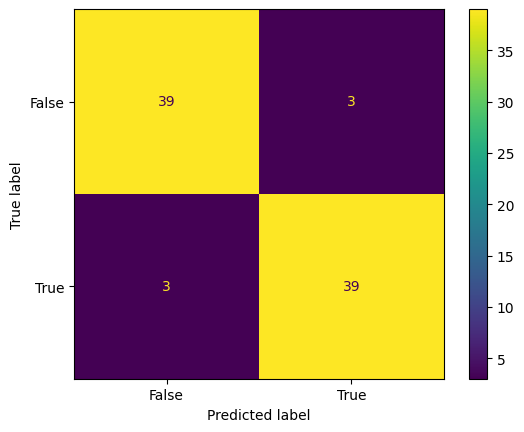

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels = RF_Optimise.classes_)

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = RF_Optimise.classes_)

display.plot()

The model was accurate at predicting the different sexes other than the six times it was predicted incorrectly.

Let's now visualise the importance of each feature so we can better understand how the model is making decisions.

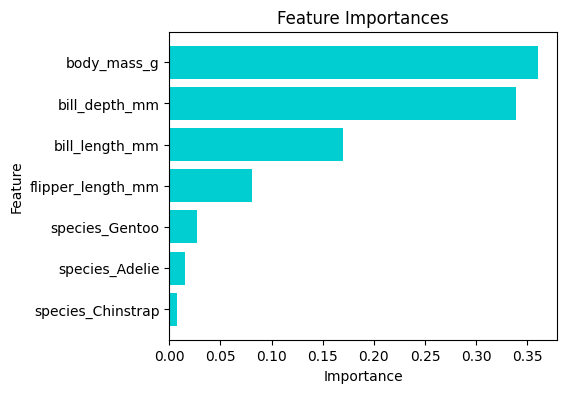

In [ ]:
feature_importance = RF_Optimise.best_estimator_.feature_importances_

plt.figure(figsize=(5,4))
feature_importance_df = pd.DataFrame({'Feature':X.columns, 'Importance':feature_importance})
feature_importance_df = feature_importance_df.sort_values('Importance')
plt.barh(y=feature_importance_df['Feature'], width=feature_importance_df['Importance'], color='darkturquoise')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

The graph explains body mass and bill depth as the biggest predictors of a penguin's sex. Bill length and flipper length were also considered somewhat strong predictors. The species attribute was not a strong predictor, which makes sense since each species should have an equal number of males and females.

## **Insights**

The following insights were gained from the exploratory data analysis:

- The 'Gentoo' species weighs just over 1 kg more than the other two species.
- Males are around half a kilogram heavier than females.
- There is a strong positive correlation between flipper length and body mass.
- Males have longer bills, longer flippers, deeper bills and more body mass.
- Penguins with deeper bills have shorter flipper and less body mass.

The following insights were gained from development of the models:

- The Simple Linear Regression model was reasonably good at predicting body mass given flipper length.
- The Clustering model was not perfect but not too bad, especially after refinement.
- The Random Forest model had a score of 92.9% over accuracy, precision, recall and F1-Score.
- Body mass and bill depth were the most important features for the Random Forest Model, with bill length and flipper length contributing aswell.

## **Summary**

This project displayed the entire data science lifecycle from start to finish. The penguins dataset was analysed to discover insights and build predictive models.

The following was completed in this project:

- Discovering, cleaning, validating and structuring the dataset.
- Exploring the data through a series of visualisations.
- Constructing a Simple Linear Regression Model, a K-Means Clustering model and a Random Forest Classification model.
- Optimising the models to produce the best results and evaluating the models to understand their performance.
- Summary of insights gained.

# **Thank you for reading!**